# 03 — Variational Quantum Circuits & Quantum Neural Networks
### QML Curriculum · Companion Notebook to Module 9 — *Core QML Algorithms (Part 1)*

**Part of:** [Schrödinger's Cats — Quantum Machine Learning Platform](https://tanjinadnanabir.github.io/WISER-Education-Challenge/)

You now know how to get data **into** a circuit (Notebook 02). This notebook builds the part that actually **learns**: a **Parameterized Quantum Circuit (PQC)** with trainable weights, optimized end-to-end with gradients — exactly like a classical neural network layer, just built from qubits and gates.

**By the end of this notebook you will be able to:**
- Build a Parameterized Quantum Circuit (PQC) with trainable weights
- Understand the "encode → variational layers → measure" QNN pattern
- Compute quantum gradients with the **parameter-shift rule**
- Train a real **Quantum Neural Network binary classifier** on a toy dataset
- Visualize the trained decision boundary

**Prerequisites:** Notebooks 01–02, Module 9 (conceptual).


In [1]:
# Setup
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import MinMaxScaler

np.random.seed(42)
print("PennyLane version:", qml.__version__)

PennyLane version: 0.45.1


## 1. Anatomy of a Variational Quantum Circuit (VQC)

Every VQC follows the same three-part recipe:

1. **Encode** — load classical data in (angle encoding, from Notebook 02)
2. **Variational layers** — trainable rotation gates + entangling gates, repeated
3. **Measure** — read out an expectation value, used as the model's prediction

Let's build one layer at a time so each piece is visible before we chain them.

In [2]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

def encode(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)

def variational_layer(weights):
    # weights shape: (n_qubits, 3) -- one general rotation per qubit
    for i in range(n_qubits):
        qml.Rot(weights[i, 0], weights[i, 1], weights[i, 2], wires=i)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])

@qml.qnode(dev)
def vqc(x, weights):
    encode(x)
    for layer_weights in weights:
        variational_layer(layer_weights)
    return qml.expval(qml.PauliZ(0))

# weights shape: (n_layers, n_qubits, 3)
n_layers = 2
weights = pnp.random.uniform(0, 2 * np.pi, size=(n_layers, n_qubits, 3), requires_grad=True)
x_sample = np.array([0.5, 1.2])

print("Output for one sample:", vqc(x_sample, weights))
print()
print(qml.draw(vqc)(x_sample, weights))

Output for one sample: 0.3983376279931241

0: ──RY(0.50)──Rot(1.15,4.90,3.75)─╭●──Rot(2.10,0.90,4.09)─╭●─┤  <Z>
1: ──RY(1.20)──Rot(2.80,0.63,2.89)─╰X──Rot(0.35,4.54,5.90)─╰X─┤     


## 2. How Do You Take a Gradient of a Quantum Circuit?

Classical backprop doesn't apply directly inside a quantum device. Instead, PennyLane uses the **parameter-shift rule**: for many common gates, the exact gradient equals the difference between the circuit evaluated with the parameter shifted by `+π/2` and `−π/2`.

```
∂⟨O⟩/∂θ = [ f(θ + π/2) − f(θ − π/2) ] / 2
```

You never need to implement this by hand — `qml.grad` does it automatically — but let's verify it manually once, so it isn't a black box.

In [3]:
dev1 = qml.device("default.qubit", wires=1)

@qml.qnode(dev1)
def simple_circuit(theta):
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

theta_val = 0.8

# Manual parameter-shift gradient
shift = np.pi / 2
manual_grad = (simple_circuit(theta_val + shift) - simple_circuit(theta_val - shift)) / 2

# PennyLane's automatic gradient
auto_grad_fn = qml.grad(simple_circuit)
auto_grad = auto_grad_fn(pnp.array(theta_val, requires_grad=True))

# Analytic derivative of cos(theta) is -sin(theta)
analytic_grad = -np.sin(theta_val)

print(f"Manual parameter-shift gradient: {manual_grad:.5f}")
print(f"PennyLane qml.grad result:       {auto_grad:.5f}")
print(f"Known analytic derivative:       {analytic_grad:.5f}")
print("\nAll three match -- this is the mechanism every training loop below relies on.")

Manual parameter-shift gradient: -0.71736
PennyLane qml.grad result:       -0.71736
Known analytic derivative:       -0.71736

All three match -- this is the mechanism every training loop below relies on.


## 3. A Real Dataset: Two Interleaving Moons

Let's give our QNN something genuinely non-linear to classify — the classic "moons" dataset. We'll scale features into `[0, π]` so they map cleanly onto rotation angles (recall Notebook 02's angle-encoding sweep).

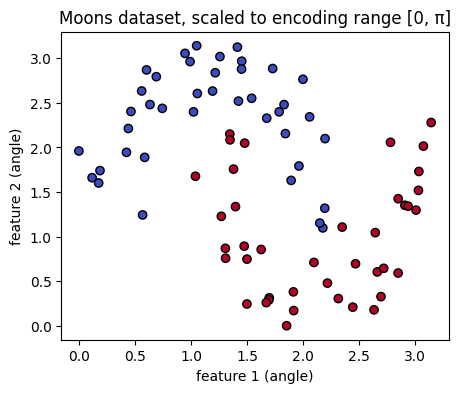

Dataset shape: (80, 2) | Labels: [-1  1]


In [4]:
X_raw, y_raw = make_moons(n_samples=80, noise=0.15, random_state=42)
scaler = MinMaxScaler(feature_range=(0, np.pi))
X = scaler.fit_transform(X_raw)
y = np.where(y_raw == 0, -1, 1)  # relabel to {-1, +1} to match a PauliZ expectation target

plt.figure(figsize=(5, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.title("Moons dataset, scaled to encoding range [0, \u03C0]")
plt.xlabel("feature 1 (angle)")
plt.ylabel("feature 2 (angle)")
plt.show()

print("Dataset shape:", X.shape, "| Labels:", np.unique(y))

## 4. Building & Training the QNN Classifier

We reuse the exact `vqc` circuit from Section 1. The **cost function** is mean-squared error between the circuit's `⟨Z⟩` output (a number in `[-1, 1]`) and the true label (also `-1` or `+1`) — precisely how a classical regression-style classifier is trained.

In [5]:
n_layers = 3
weights = pnp.random.uniform(0, 2 * np.pi, size=(n_layers, n_qubits, 3), requires_grad=True)
bias = pnp.array(0.0, requires_grad=True)

def predict(x, weights, bias):
    return vqc(x, weights) + bias

def cost(weights, bias, X, y):
    predictions = pnp.stack([predict(x, weights, bias) for x in X])
    return pnp.mean((predictions - y) ** 2)

def accuracy(weights, bias, X, y):
    preds = np.array([np.sign(predict(x, weights, bias)) for x in X])
    return np.mean(preds == y)

opt = qml.AdamOptimizer(stepsize=0.15)
n_epochs = 40
cost_history = []

for epoch in range(n_epochs):
    weights, bias = opt.step(lambda w, b: cost(w, b, X, y), weights, bias)
    if epoch % 5 == 0 or epoch == n_epochs - 1:
        c = cost(weights, bias, X, y)
        acc = accuracy(weights, bias, X, y)
        cost_history.append(c)
        print(f"Epoch {epoch:2d} | cost = {c:.4f} | accuracy = {acc*100:.1f}%")

Epoch  0 | cost = 0.7354 | accuracy = 66.2%


Epoch  5 | cost = 0.4336 | accuracy = 86.2%


Epoch 10 | cost = 0.4333 | accuracy = 87.5%


Epoch 15 | cost = 0.3889 | accuracy = 87.5%


Epoch 20 | cost = 0.3906 | accuracy = 86.2%


Epoch 25 | cost = 0.3842 | accuracy = 87.5%


Epoch 30 | cost = 0.3821 | accuracy = 87.5%


Epoch 35 | cost = 0.3819 | accuracy = 87.5%


Epoch 39 | cost = 0.3806 | accuracy = 87.5%


In [6]:
final_acc = accuracy(weights, bias, X, y)
print(f"\nFinal training accuracy: {final_acc*100:.1f}%")


Final training accuracy: 87.5%


## 5. Visualizing What the QNN Learned

Let's draw the decision boundary the trained circuit carved out across the full feature space — the quantum analogue of the decision-boundary plots you'd make for a classical logistic regression or small neural net.

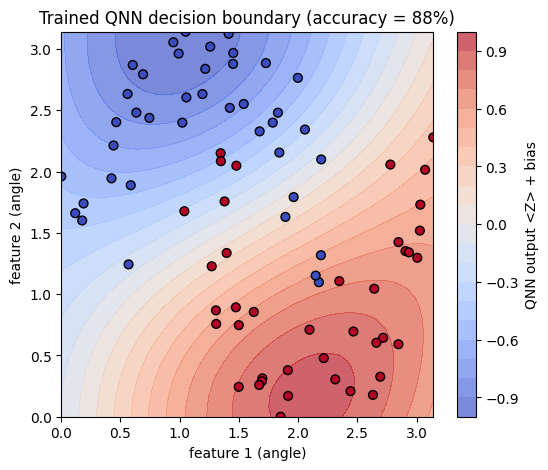

In [7]:
xx, yy = np.meshgrid(np.linspace(0, np.pi, 40), np.linspace(0, np.pi, 40))
grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = np.array([predict(pt, weights, bias) for pt in grid_points])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, levels=20, cmap="coolwarm", alpha=0.7)
plt.colorbar(label="QNN output <Z> + bias")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=40)
plt.title(f"Trained QNN decision boundary (accuracy = {final_acc*100:.0f}%)")
plt.xlabel("feature 1 (angle)")
plt.ylabel("feature 2 (angle)")
plt.show()

### 🔧 Try it yourself
The model above uses `n_layers = 3`. Retrain with `n_layers = 1` (copy the training loop into the cell below). Does accuracy get noticeably worse? This is the QNN version of a classical "too few layers to fit the data" experiment.

In [8]:
# YOUR CODE HERE -- copy the Section 4 training loop, but start from:
# weights_shallow = pnp.random.uniform(0, 2*np.pi, size=(1, n_qubits, 3), requires_grad=True)


## 6. Recap & What's Next

| Concept | What you built |
|---|---|
| PQC anatomy | encode → variational layers (`qml.Rot` + `CNOT`) → measure |
| Parameter-shift rule | Verified by hand that it matches the true analytic gradient |
| QNN training loop | Adam optimizer minimizing MSE against ±1 labels |
| Decision boundary | A real, trained non-linear classifier on the moons dataset |

**Next notebook: `04_quantum_kernels_qsvm_qpca.ipynb`** — Module 9, Part 2. Instead of training circuit weights directly, you'll use a quantum circuit to compute a **kernel** — a similarity measure between data points — and feed it into a classical Support Vector Machine.
